In [1]:
pip install lightgbm scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.


loading data...
🤖 Training Logi-Brain...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000105 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 30
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 6
[LightGBM] [Info] Start training from score 13.983900
📉 Mean Absolute Error: 6.72 tons


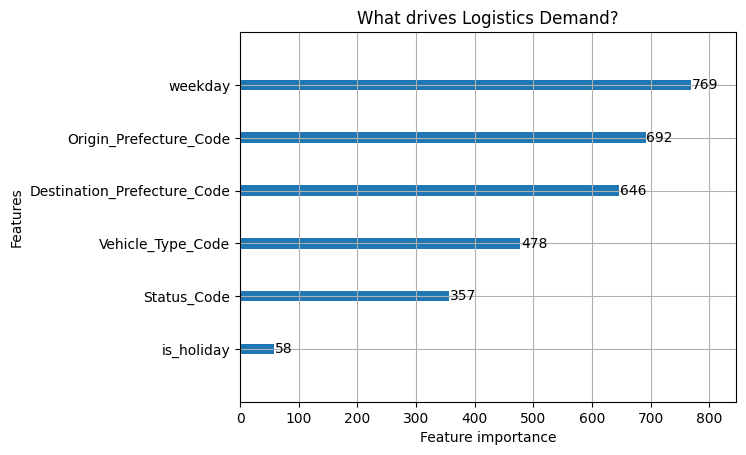

In [ ]:
import pandas as pd
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

print('loading data...')
features_df = pd.read_parquet('data/features_engineered.parquet')

# 1. Prepare X (Features) and y (Target)
features_df['is_holiday'] = features_df['is_holiday'].astype(int)

X = features_df.drop(columns=['Date', 'Cargo_Weight_Tons'])
y = features_df['Cargo_Weight_Tons']

split_point = int(len(features_df) * 0.8)

X_train = X.iloc[:split_point]
y_train = y.iloc[:split_point]
X_test = X.iloc[split_point:]
y_test = y.iloc[split_point:]

model = lgb.LGBMRegressor(
    random_state=42,
    n_estimators=100
)

print("🤖 Training Logi-Brain...")
model.fit(X_train, y_train)

predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
print(f"📉 Mean Absolute Error: {mae:.2f} tons")

lgb.plot_importance(model, max_num_features=10)
plt.title("What drives Logistics Demand?")
plt.show()